In [21]:
# Surface Wave Plots David Glacier Seismic
# Zachary Katz
# 11 December 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os
import pandas as pd
from scipy.signal import find_peaks
import scipy

############
line = '21X'
shot_str = "Y" # Options: 'X ', 'Y ', 'XX', 'YY'
geometry_path = f'./_data/KPDC_David_Seismic_2022/RAW/{line}-Geometry.csv' 
sgy_file = f'./_data/KPDC_David_Seismic_2022/RAW/{line}'
num_shots = 56 # Number of shots on this Line [X=56, Y=40, XX=28. YY=20]
############

sgy_path = sgy_file + '.sgy'

def segyload_obspy_obj(sgy_path, fldr_number=1):
    # Load entire SEG-Y file
    st = _read_segy(sgy_path, unpack_trace_headers=True)

    # Sampling values
    dt = st[0].stats.delta          # seconds
    print(dt)
    ns = st[0].stats.npts
    time = np.arange(ns) * dt       # seconds

    # Select traces based on Field Record Number (fldr)
    selected_traces = []
    coords = {'source_x': [], 'source_y': [], 'group_x': [], 'group_y': []}
    for tr in st:
        hdr = tr.stats.segy.trace_header
        if hdr.original_field_record_number == fldr_number:
            selected_traces.append(tr)
            coords['source_x'].append(hdr.source_coordinate_x)
            coords['source_y'].append(hdr.source_coordinate_y)
            coords['group_x'].append(hdr.group_coordinate_x)
            coords['group_y'].append(hdr.group_coordinate_y)

    if len(selected_traces) == 0:
        raise ValueError(f"No traces found for fldr={fldr_number}")

    return selected_traces, time, coords


0.00025


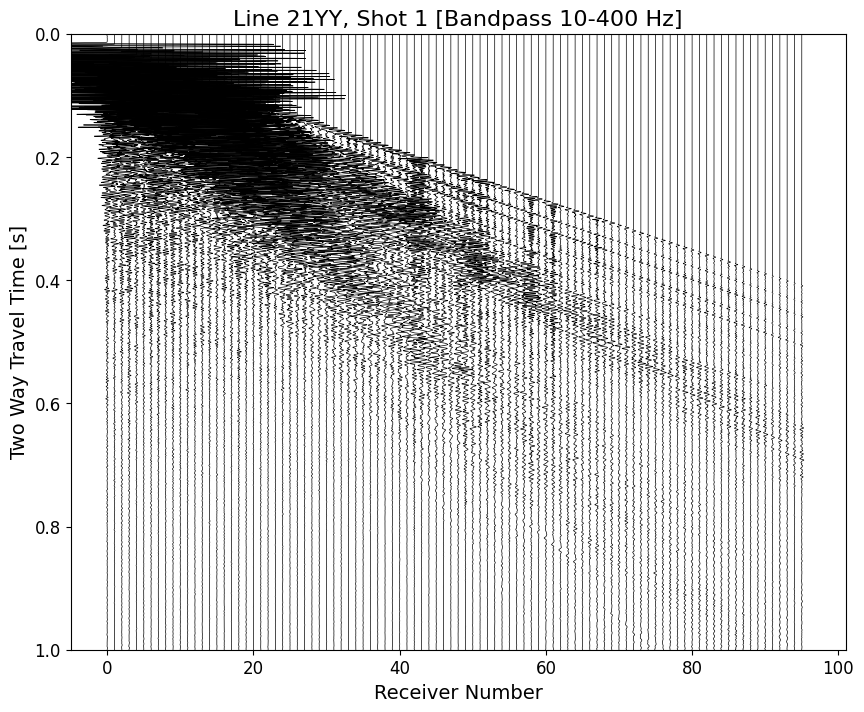

In [107]:
# Full shot filtered wiggle:
for index, fldr_number in enumerate([1]):
    fig, ax = plt.subplots(figsize=(10, 8))
    selected_traces, time, coords = segyload_obspy_obj(sgy_path, fldr_number)

    selected_trace_copys = selected_traces.copy()
    freqmax = 400
    freqmin = 10
    for tr in selected_trace_copys:
        tr.filter('bandpass', freqmin=freqmin, freqmax=freqmax)

    for i, tr in enumerate(selected_trace_copys):
        ax.plot(tr.data * 0.2 + i, time, color='black', linewidth=0.5)
    
    ax.set_xlim(-5, len(selected_traces)+5)
    ax.set_ylim(1, 0)

    ax.set_xlabel("Receiver Number",fontsize=14)
    ax.set_ylabel("Two Way Travel Time [s]",fontsize=14)
    ax.set_title(f"Line {line}, Shot {fldr_number} [Bandpass {freqmin}-{freqmax} Hz]",fontsize=16)
    ax.tick_params(labelsize=12)
    

In [104]:
dt

NameError: name 'dt' is not defined

0.00025


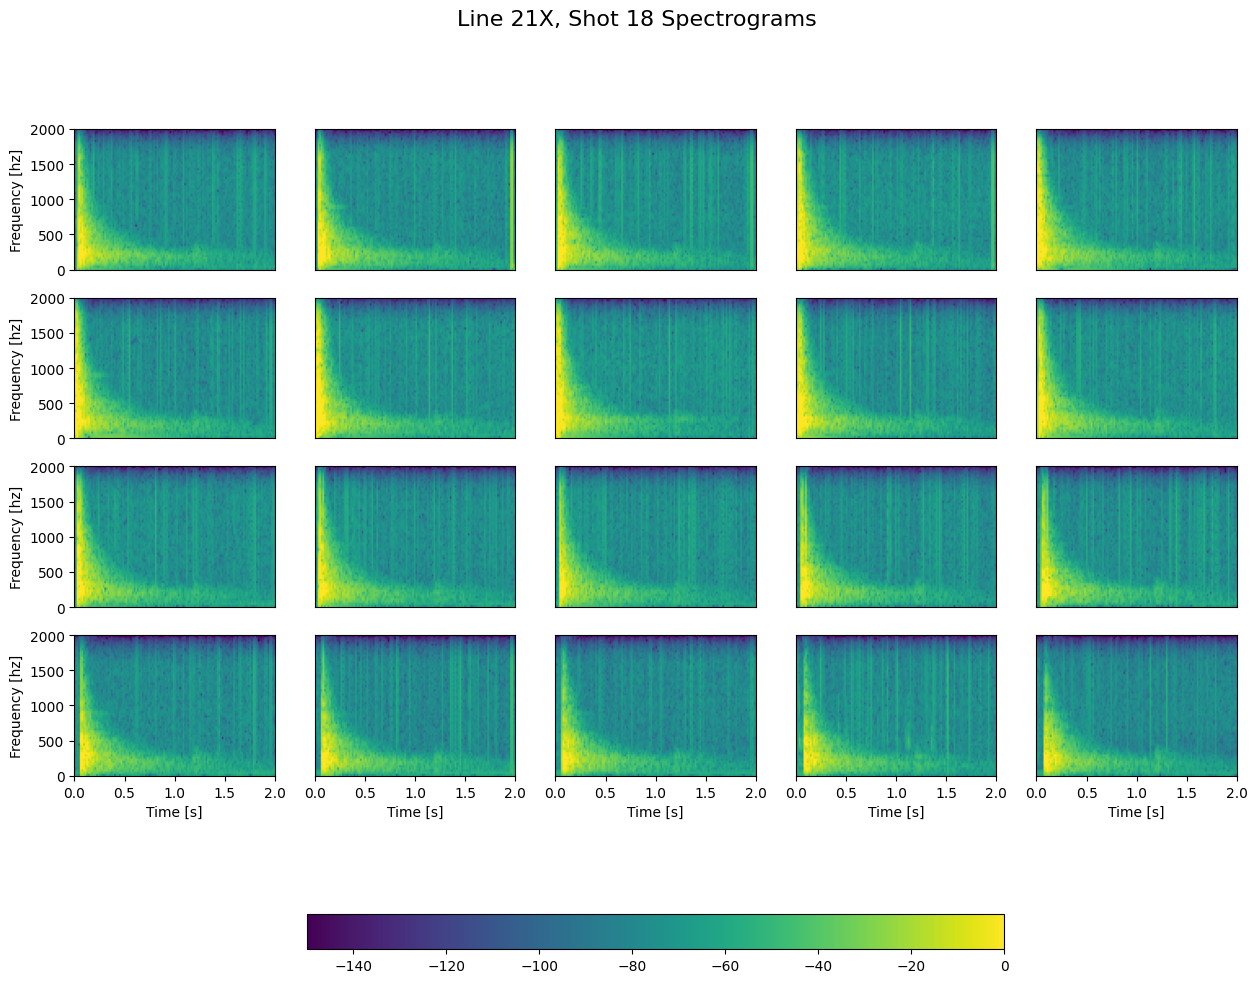

In [22]:
# Full shot spectrogram:
for index, fldr_number in enumerate([18]):
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # 20 traces
    selected_traces, time, coords = segyload_obspy_obj(sgy_path, fldr_number)

    selected_trace_copys = selected_traces.copy()
    axes = axes.ravel()

    fs = 1.0 / (time[1] - time[0])

    # Plot spectrogram for the first 20 traces (or fewer if not enough)
    n_plot = min(20, len(selected_traces))

    for i in range(n_plot):
        ax = axes[i]
        tr = selected_trace_copys[i].data

        Pxx, freqs, bins, im = ax.specgram(
            tr,
            NFFT=128,
            Fs=fs,
            noverlap=63,
            cmap='viridis'
        )
        ax.set_xlim(0,2)
        ax.set_ylim(0,2000)

        ax.set_xticks([])
        ax.set_yticks([])
        #print(im.get_clim())
        im.set_clim(-150, 0)


    # X labels on bottom row (row = 3 → indices 15–19)
    for j in range(15, 20):
        if j < n_plot:
            axes[j].set_axis_on()
            axes[j].set_xlabel("Time [s]", fontsize=10)
            axes[j].set_xticks([0, 0.5, 1.0, 1.5, 2.0])

    # Y labels on left column (indices: 0,5,10,15)
    for j in [0, 5, 10, 15]:
        if j < n_plot:
            axes[j].set_axis_on()
            axes[j].set_ylabel("Frequency [hz]", fontsize=10)
            axes[j].set_yticks([0, 500, 1000, 1500, 2000])

    cbar = fig.colorbar(im, ax=axes, shrink=0.6, location='bottom')

    fig.suptitle(f"Line {line}, Shot {fldr_number} Spectrograms", fontsize=16)

In [23]:
# Stacked spectra
db_stacks = []
db_bins = []
fldr_numbers = []
for index, fldr_number in enumerate(range(1, num_shots+1)):
    try:
        print(index)

        selected_traces, time, coords = segyload_obspy_obj(sgy_path, fldr_number)
        selected_trace_copys = selected_traces.copy()
        # Plot spectrogram for the first 20 traces (or fewer if not enough)
        n_plot =len(selected_traces)

        specs = []
        for i in range(n_plot):
            tr = selected_trace_copys[i].data

            Pxx, freqs, bins, im = ax.specgram(
                tr,
                NFFT=256,
                Fs=fs,
                noverlap=128,
                cmap='viridis'
            )
        specs.append(Pxx)


        S_stack = np.vstack(specs) 
        db_stacks.append(10*np.log10(S_stack + 1e-12))
        db_bins.append(freqs)
        fldr_numbers.append(fldr_number)

    except:
        continue
    """
    plt.figure(figsize=(12, 6))

    plt.imshow(
        10*np.log10(S_stack + 1e-12),  # dB scale
        aspect="auto",
        origin="lower",
        extent=[bins.min(), bins.max(), 0, 2000],
        cmap="viridis"
    )

    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.title(f"Shot {fldr_number}, Line {line} Stacked")
    plt.colorbar(label="Power [dB]")
    plt.show()
    """

0
0.00025
1
0.00025
2
0.00025


/home/zkatz/Research/david_seismic/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


3
0.00025
4
0.00025
5
0.00025
6
0.00025
7
0.00025
8
0.00025
9
0.00025
10
0.00025
11
0.00025
12
0.00025
13
0.00025
14
0.00025
15
0.00025
16
0.00025
17
0.00025
18
0.00025
19
0.00025
20
0.00025
21
0.00025
22
0.00025
23
0.00025
24
0.00025
25
0.00025
26
0.00025
27
0.00025
28
0.00025
29
0.00025
30
0.00025
31
0.00025
32
0.00025
33
0.00025
34
0.00025
35
0.00025
36
0.00025
37
0.00025
38
0.00025
39
0.00025
40
0.00025
41
0.00025
42
0.00025
43
0.00025
44
0.00025
45
0.00025
46
0.00025
47
0.00025
48
0.00025
49
0.00025
50
0.00025
51
0.00025
52
0.00025
53
0.00025
54
0.00025
55
0.00025


129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129


/tmp/ipykernel_50391/953842862.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 6))


129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129
129


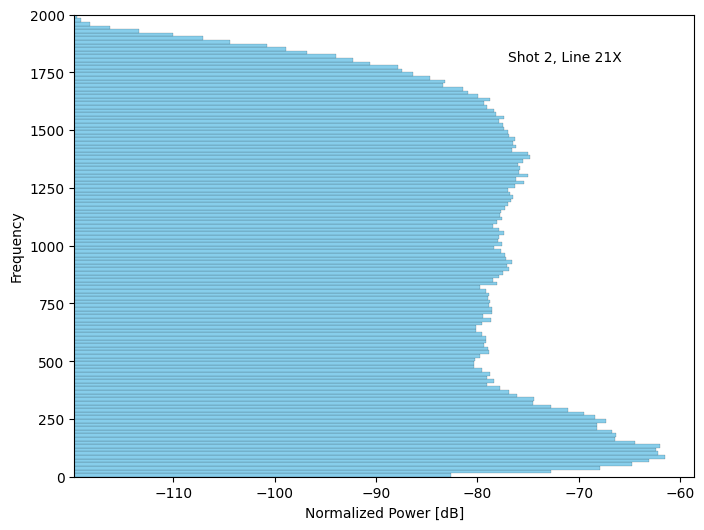

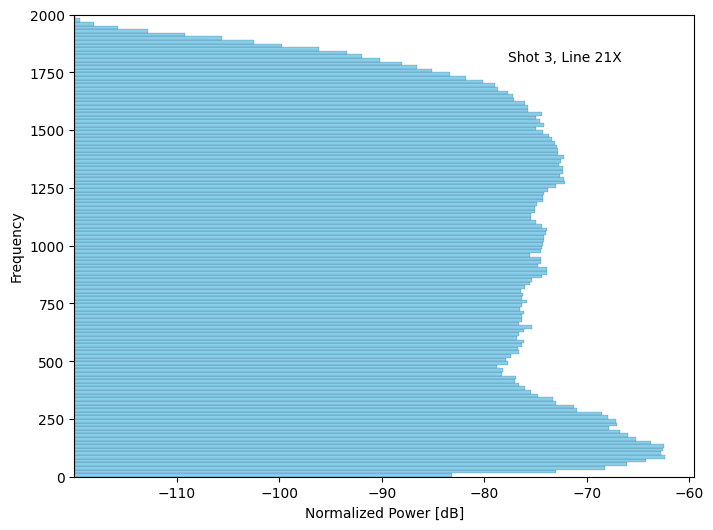

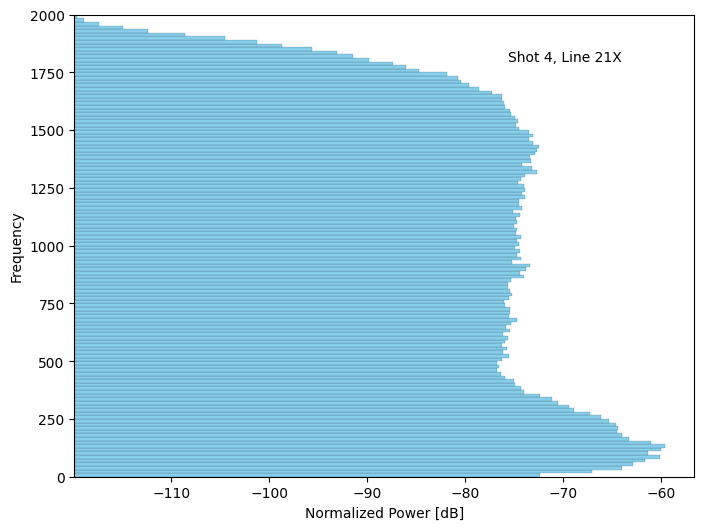

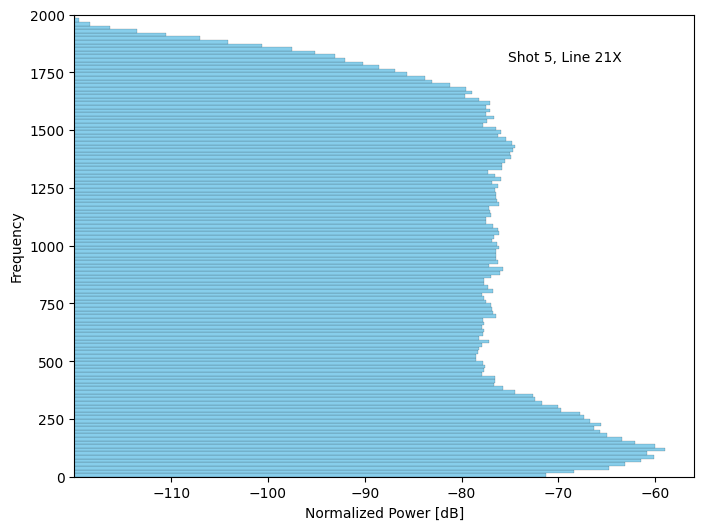

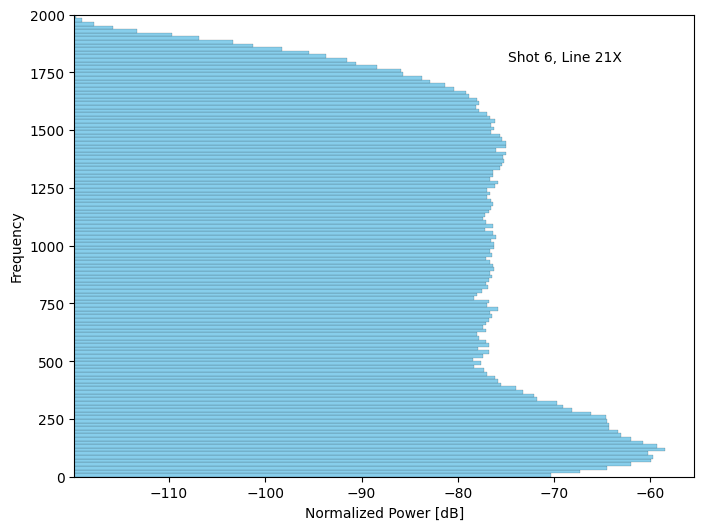

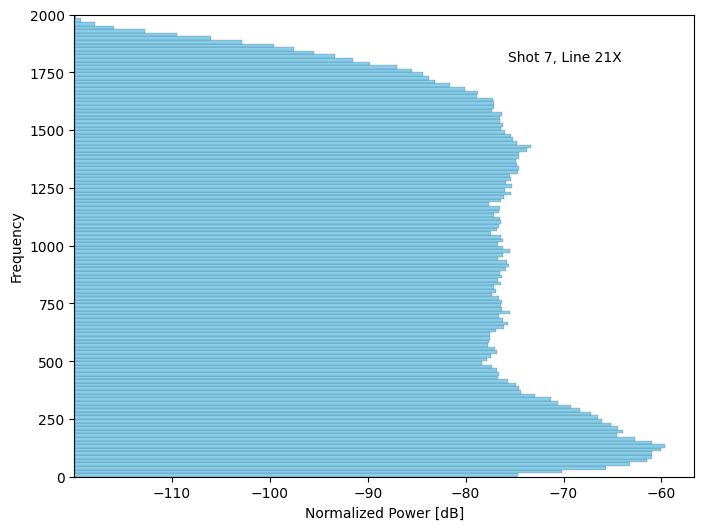

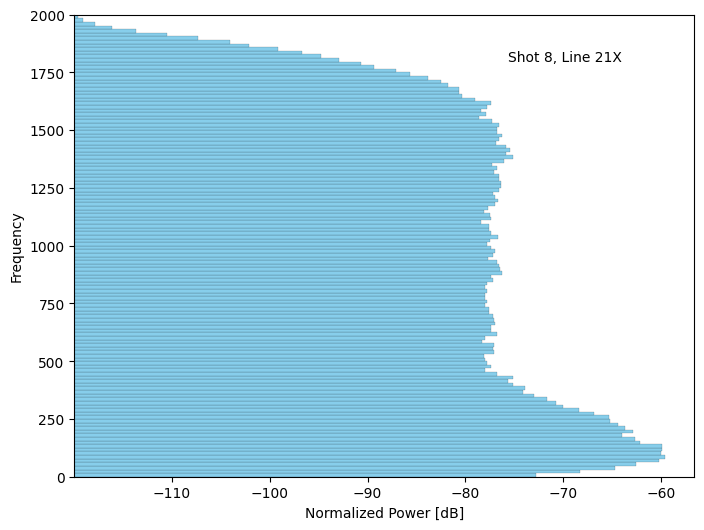

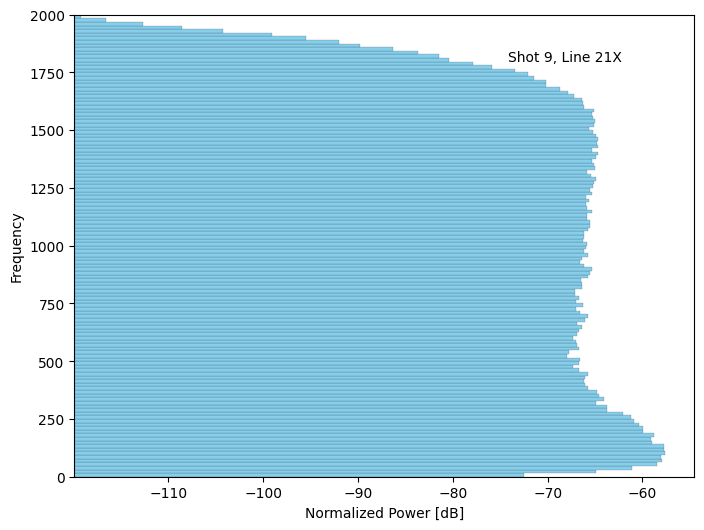

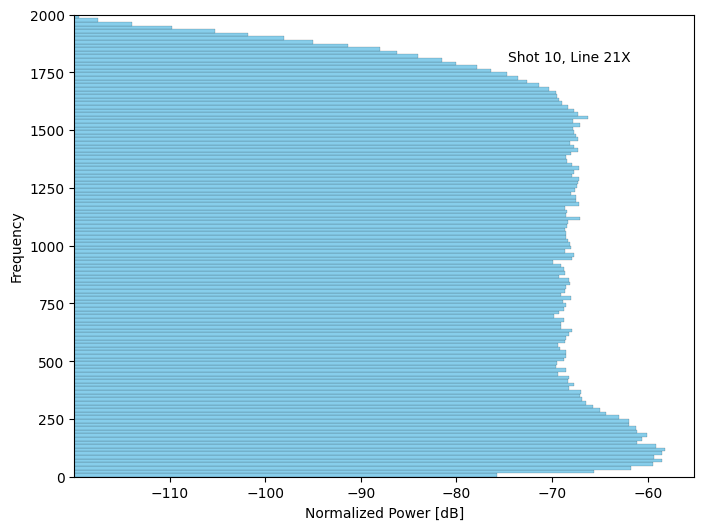

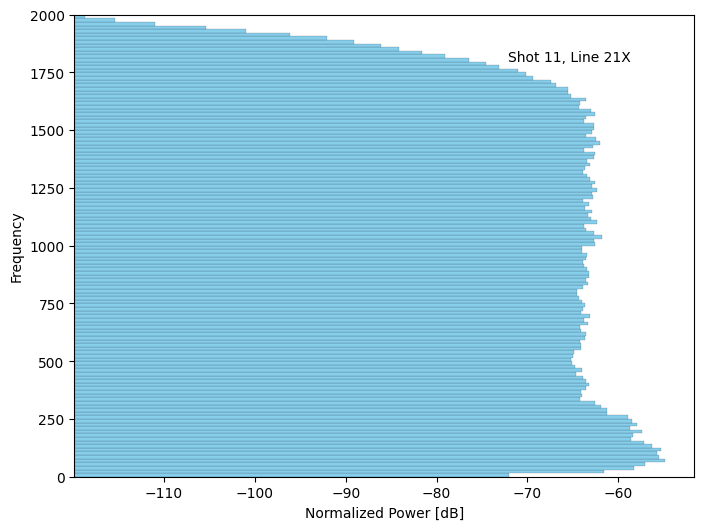

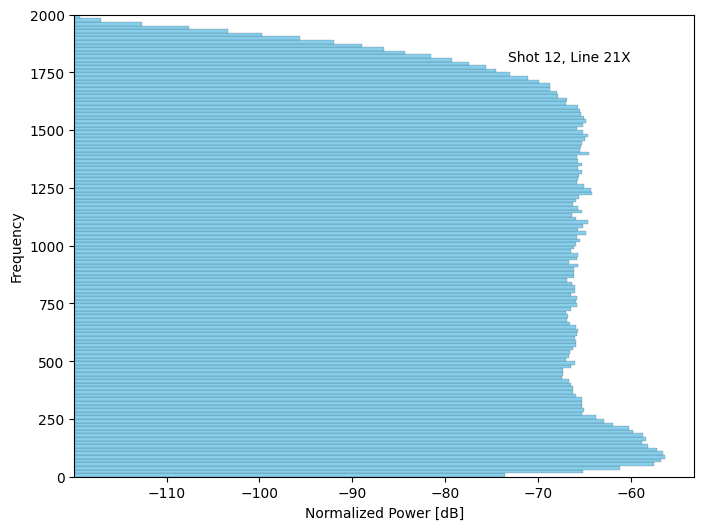

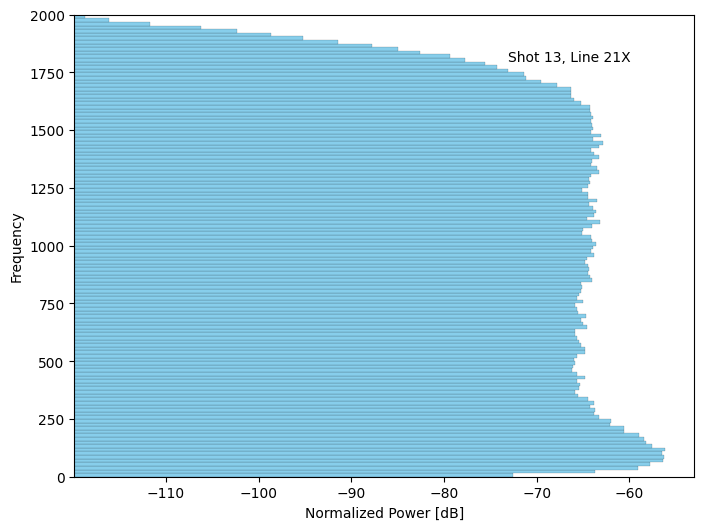

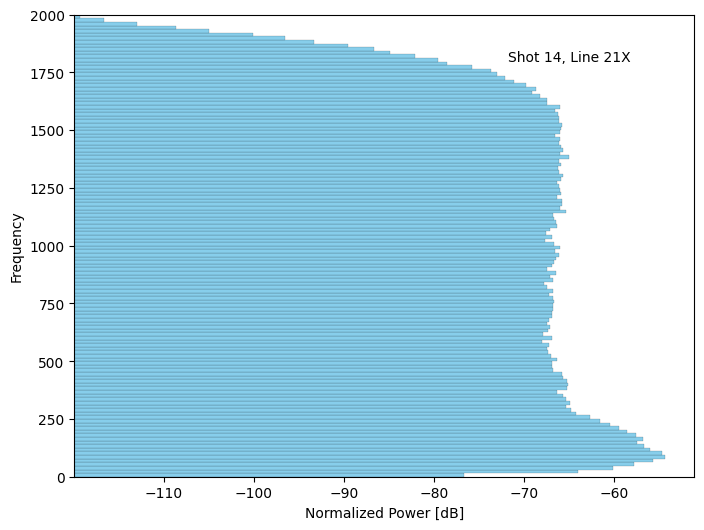

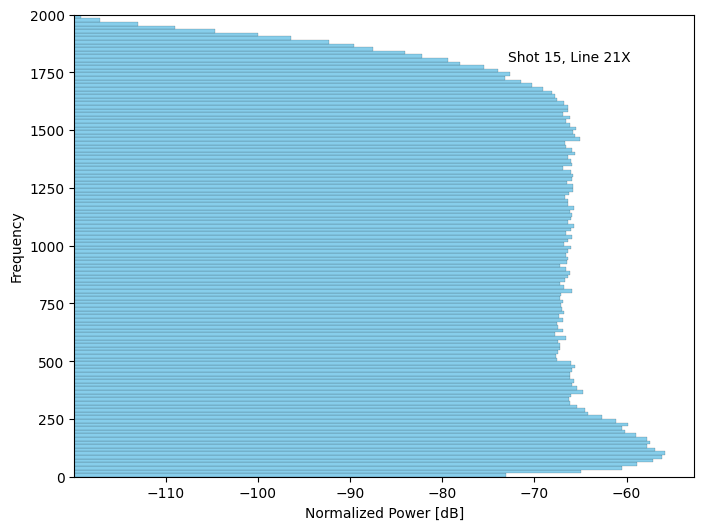

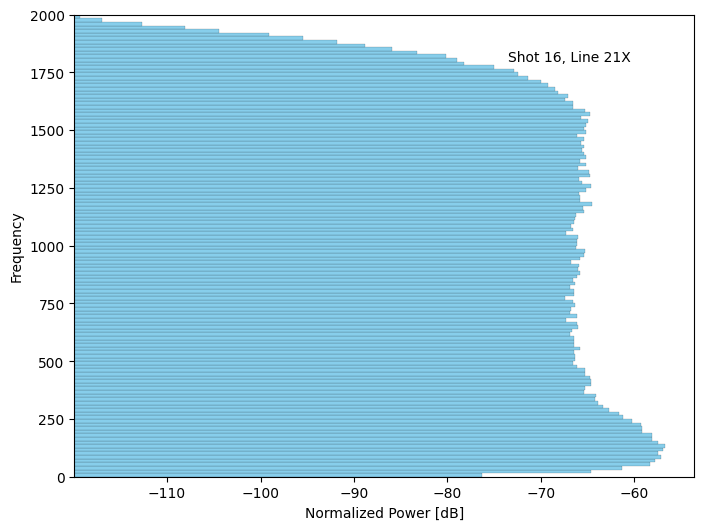

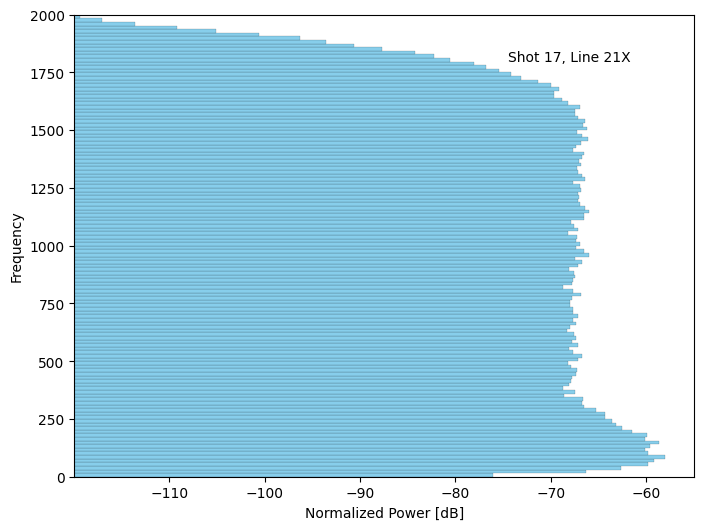

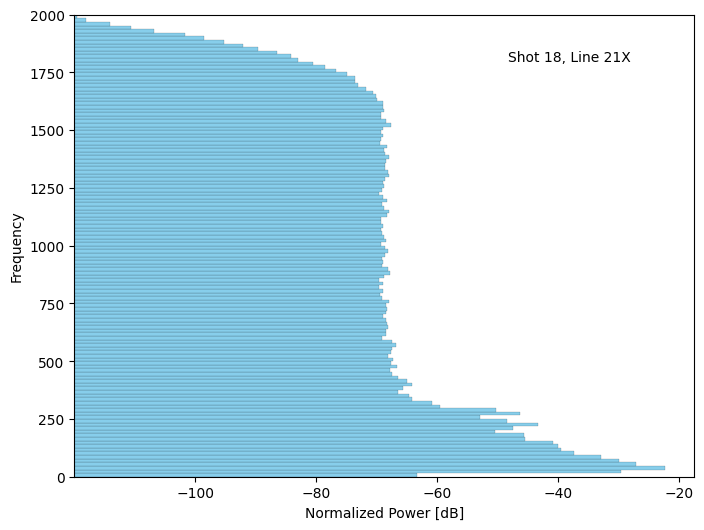

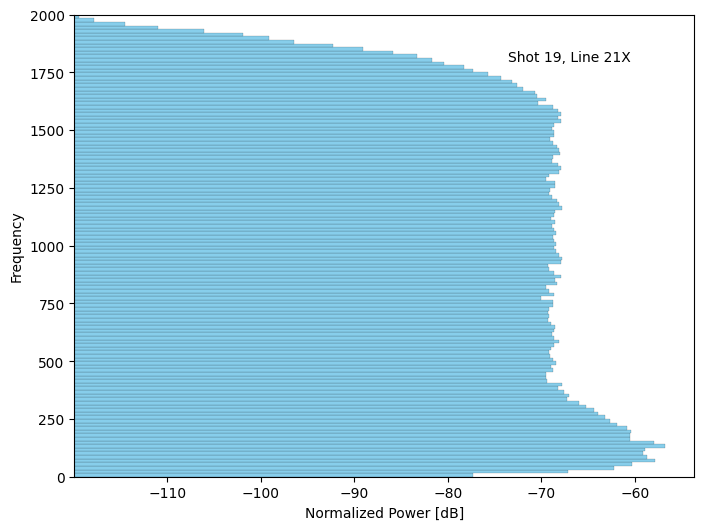

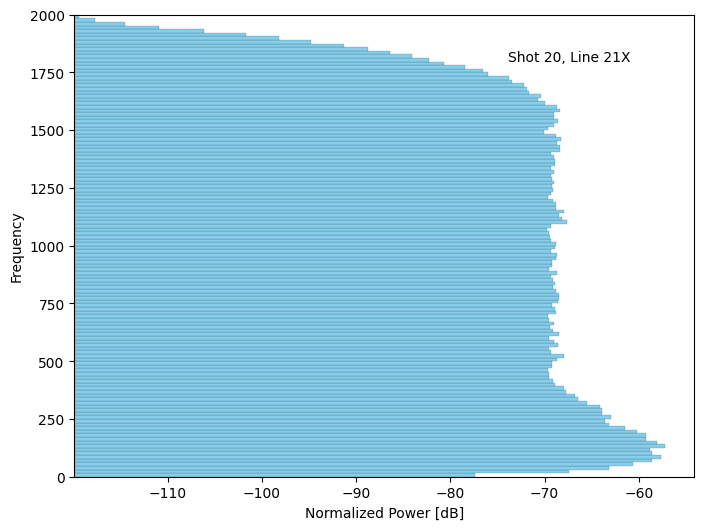

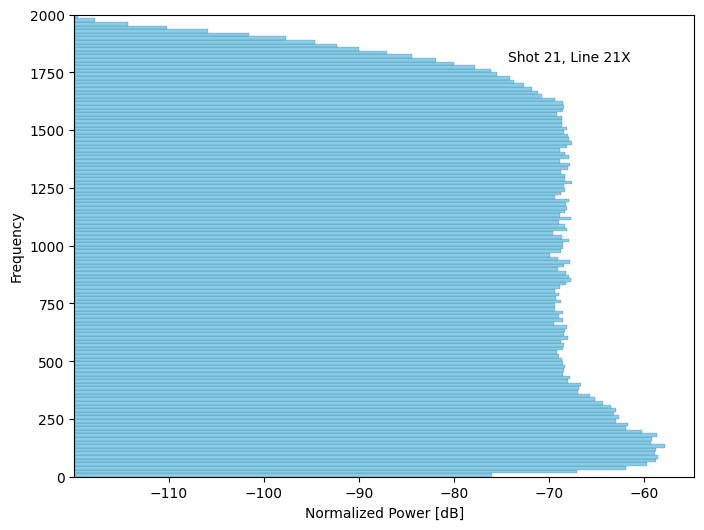

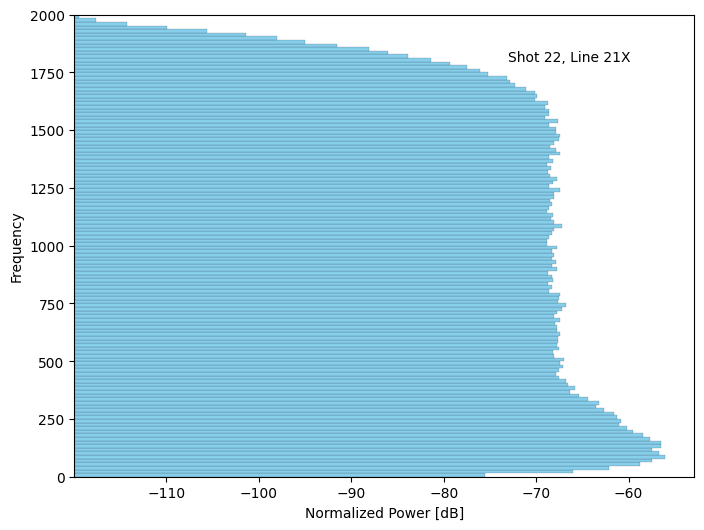

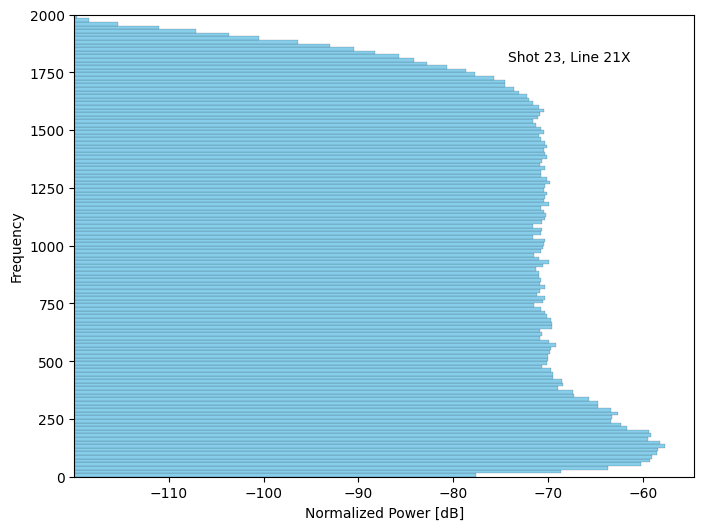

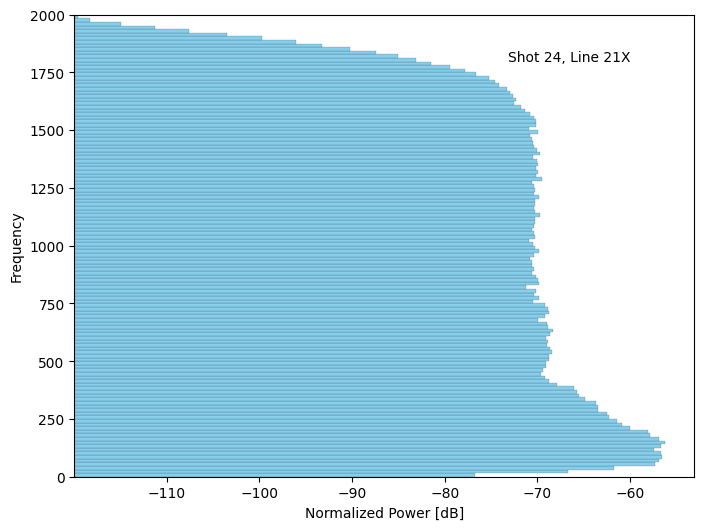

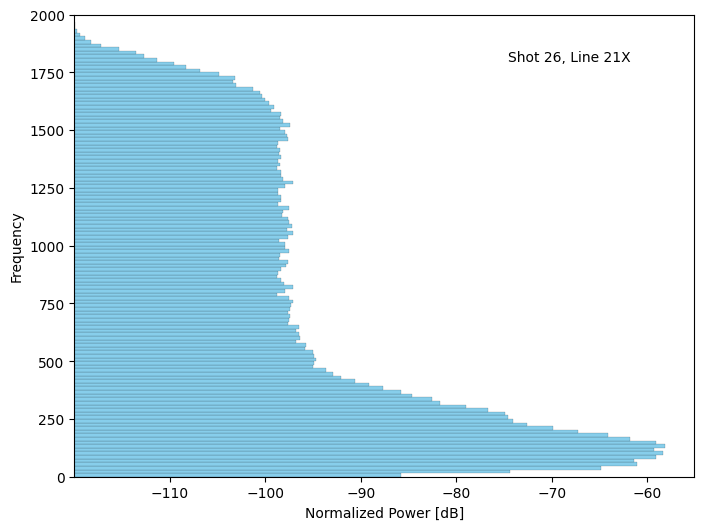

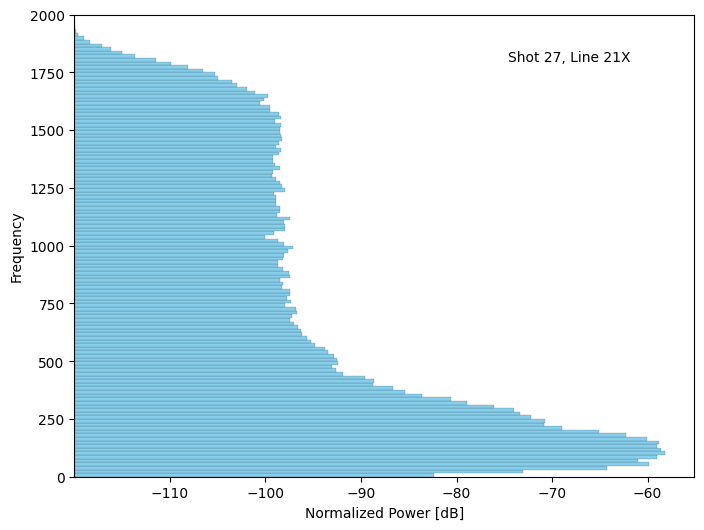

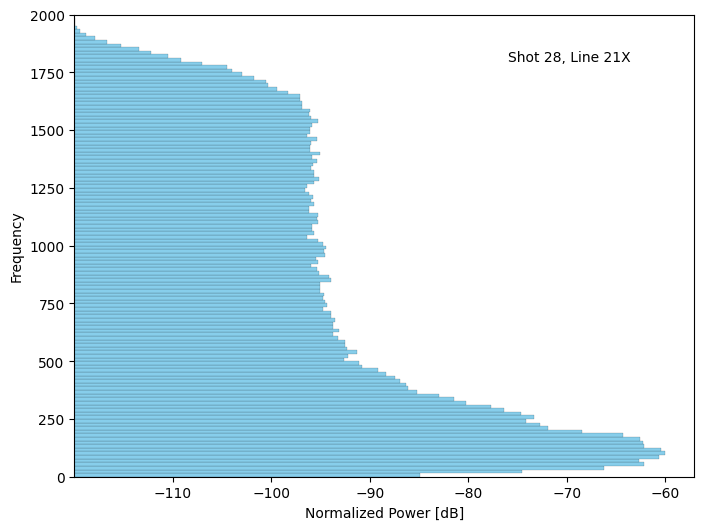

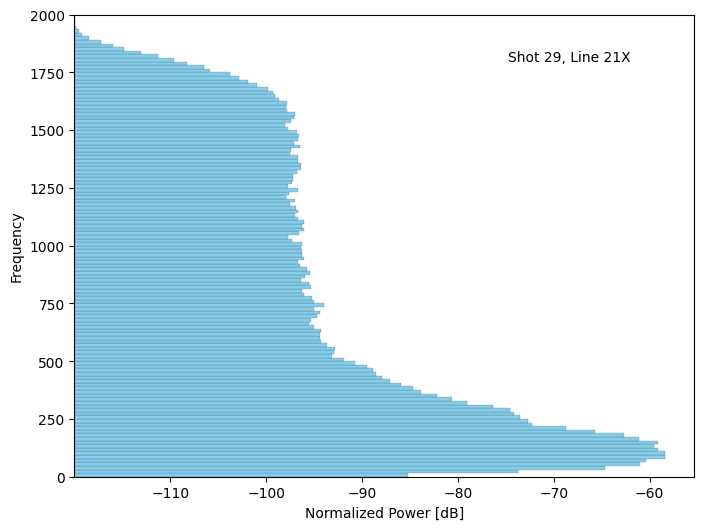

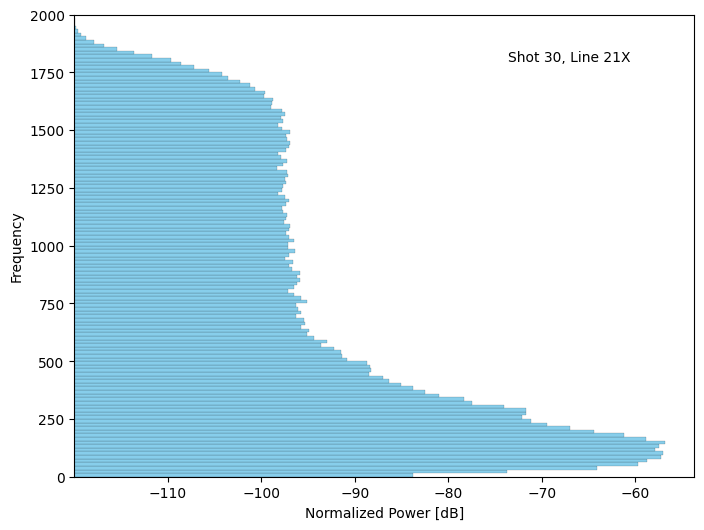

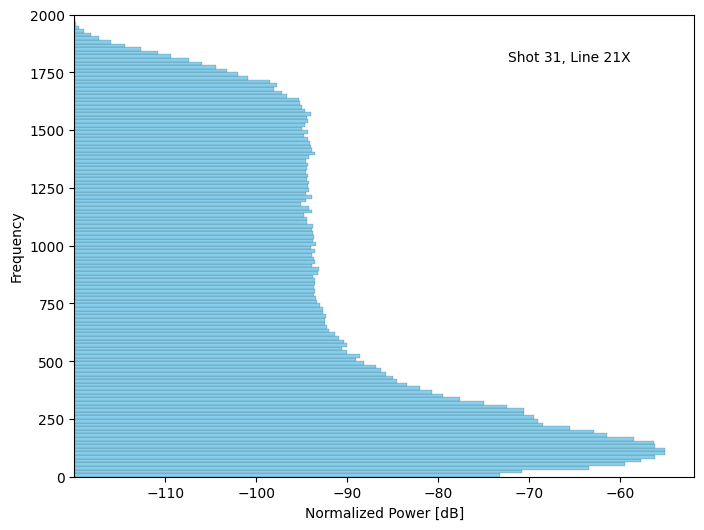

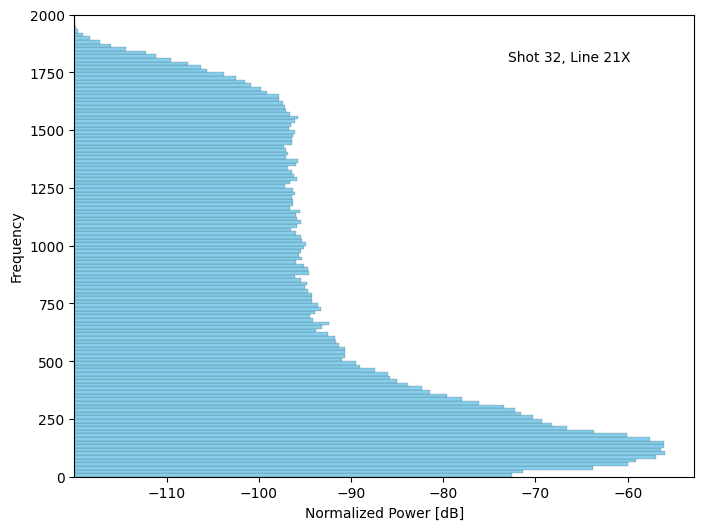

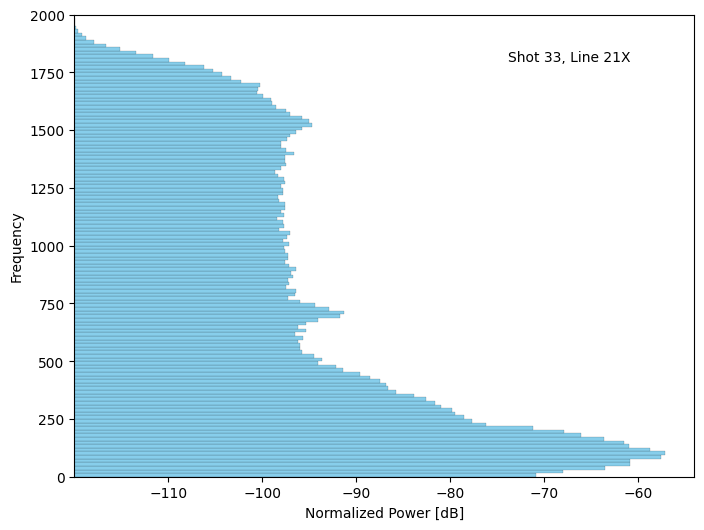

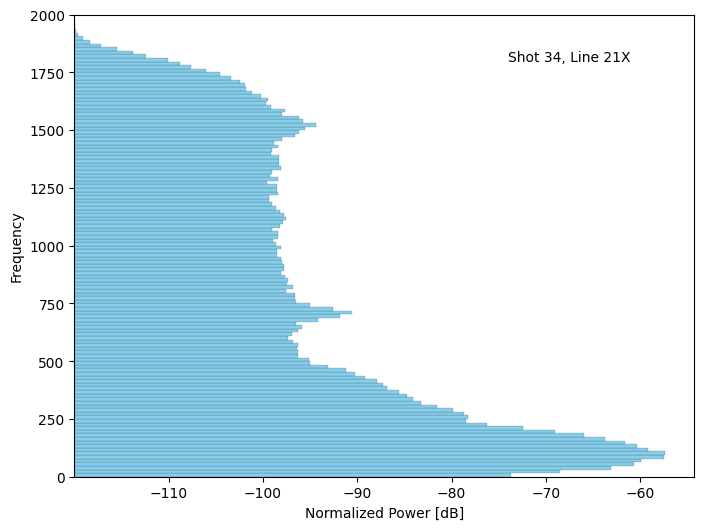

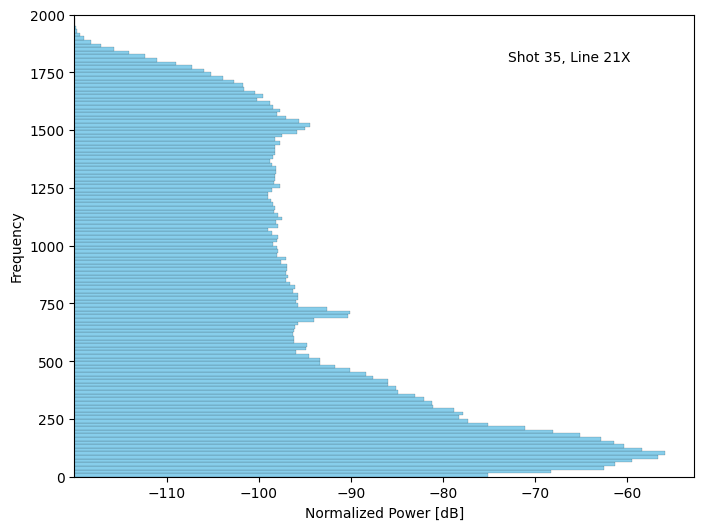

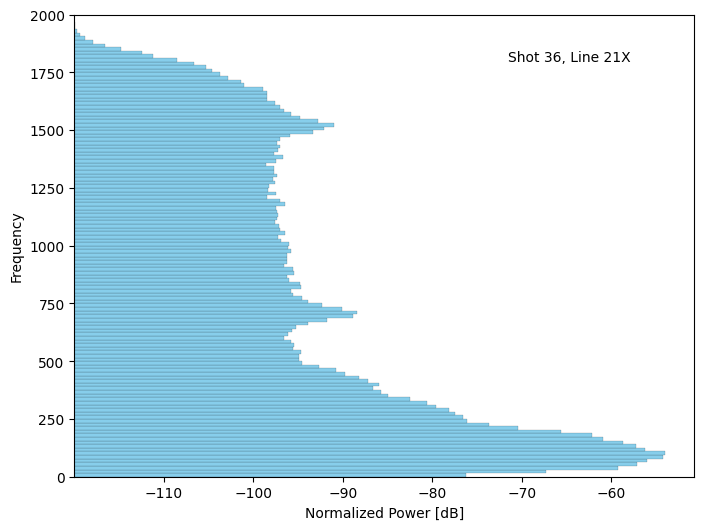

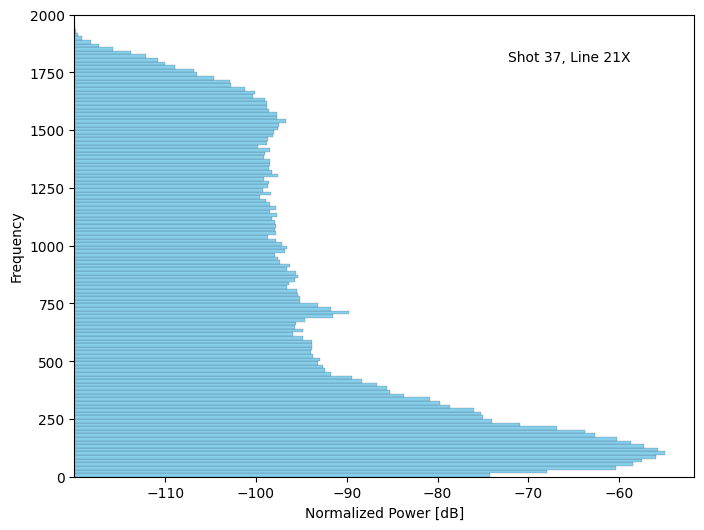

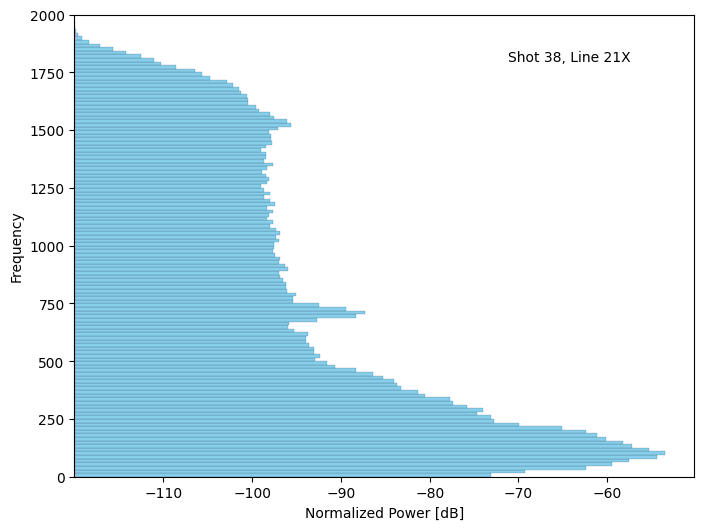

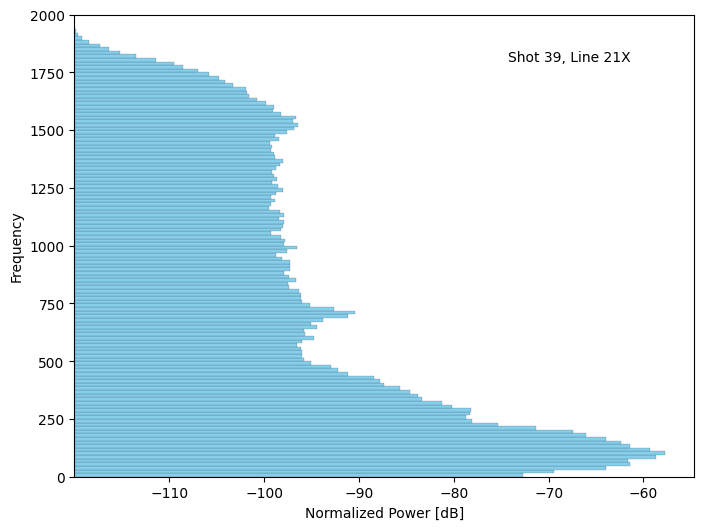

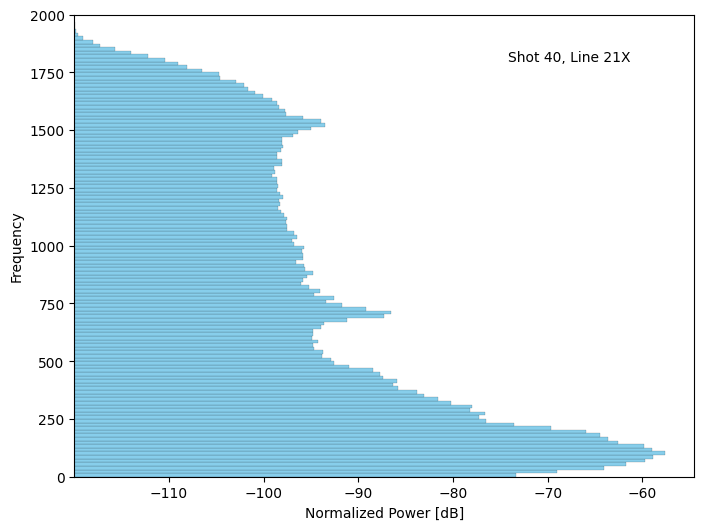

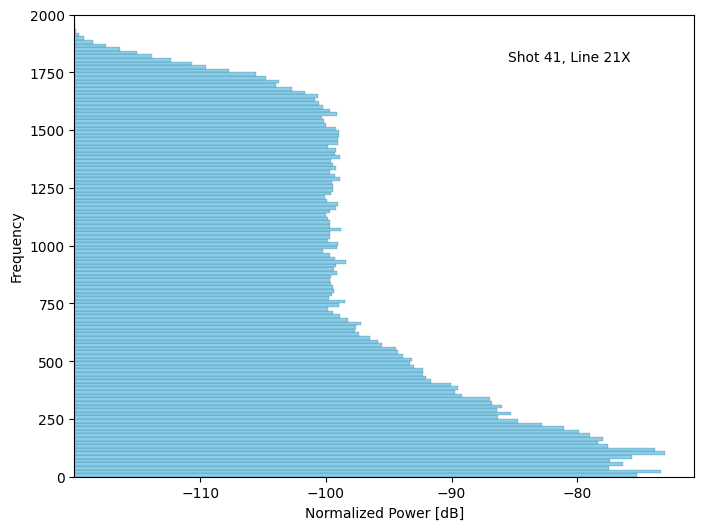

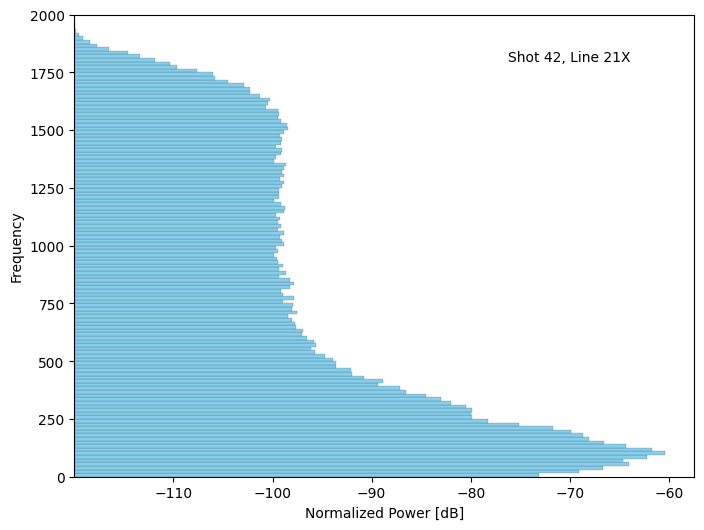

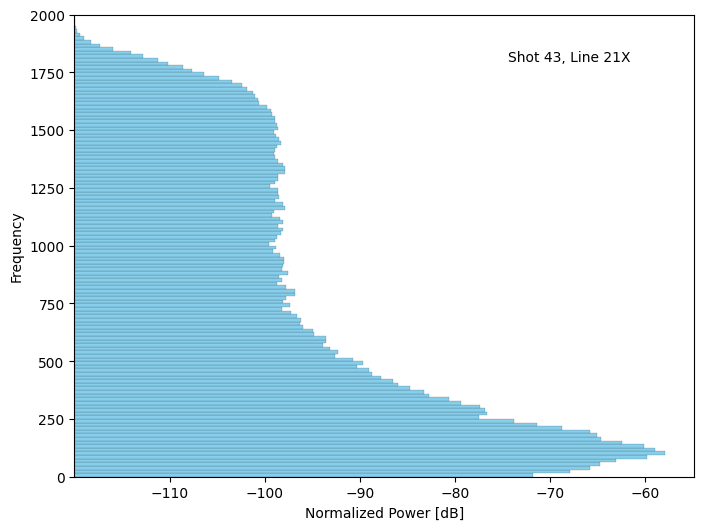

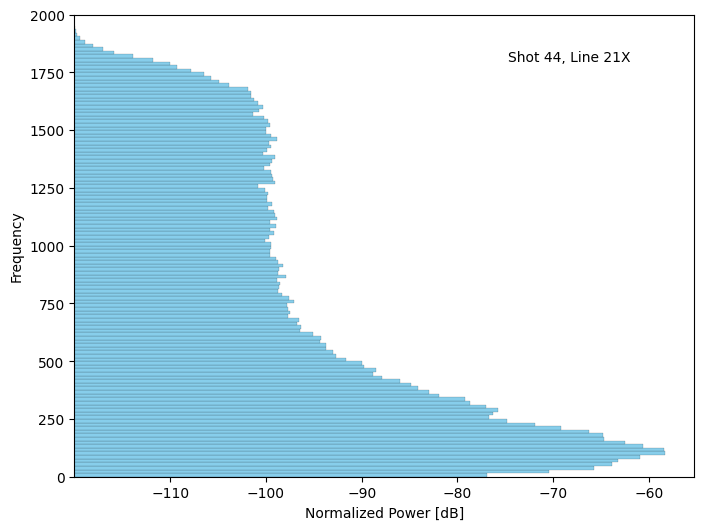

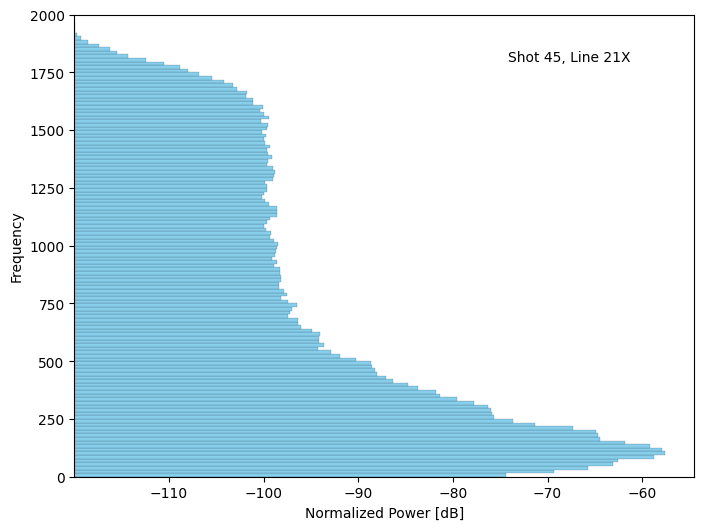

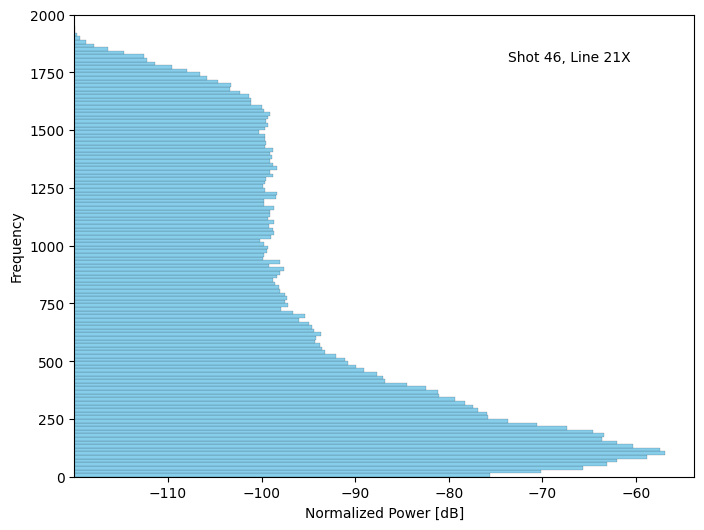

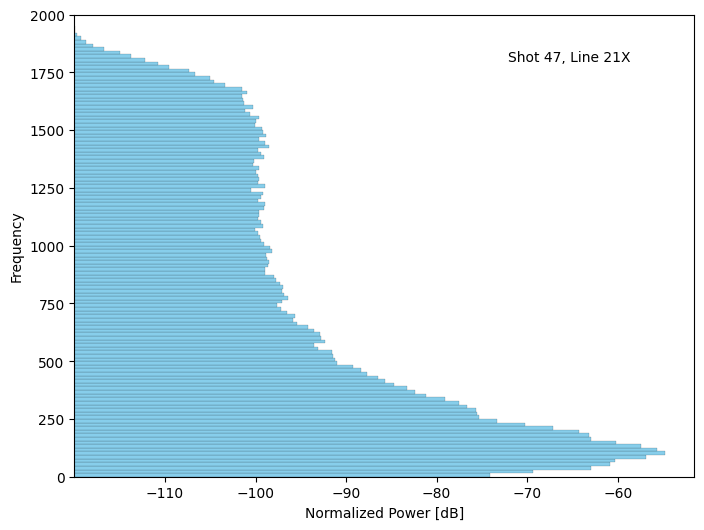

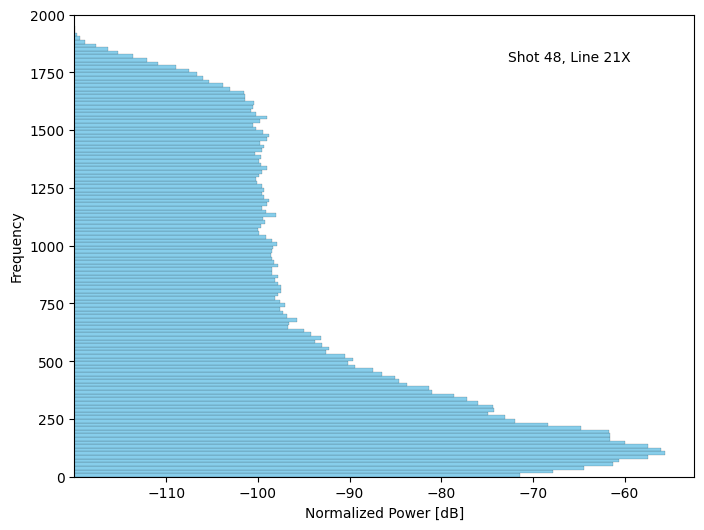

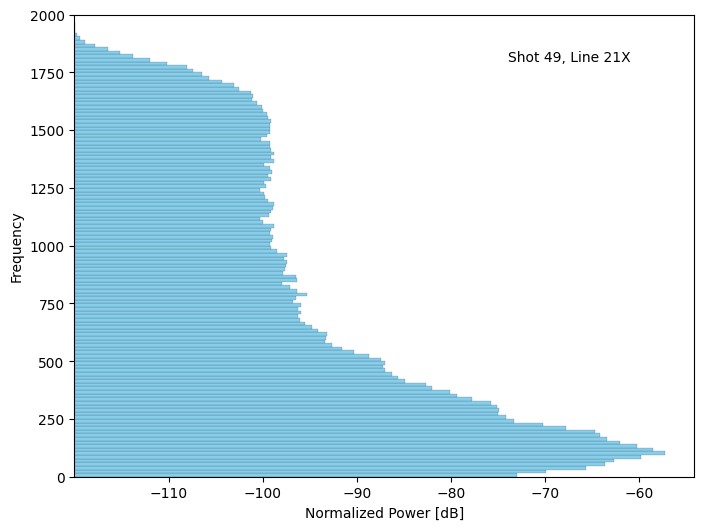

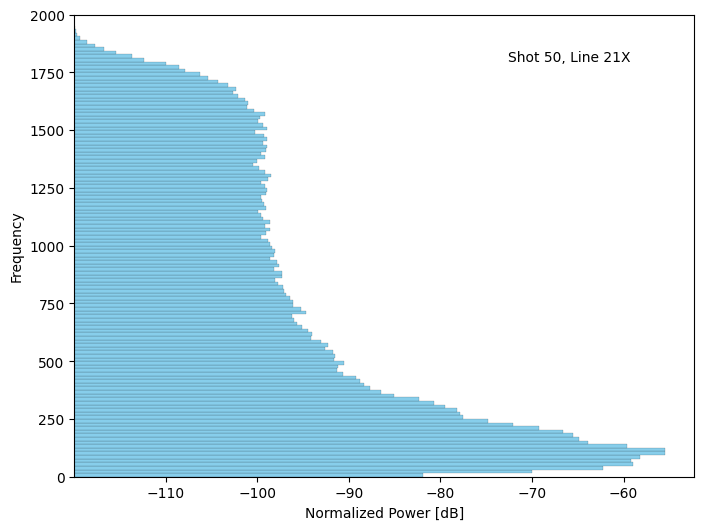

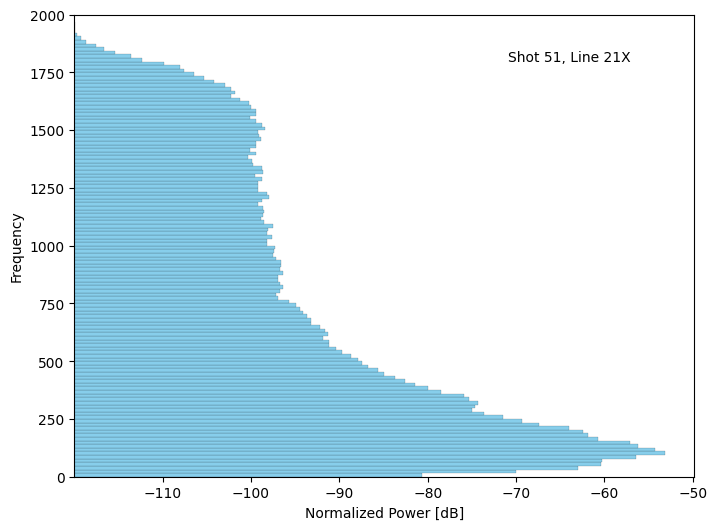

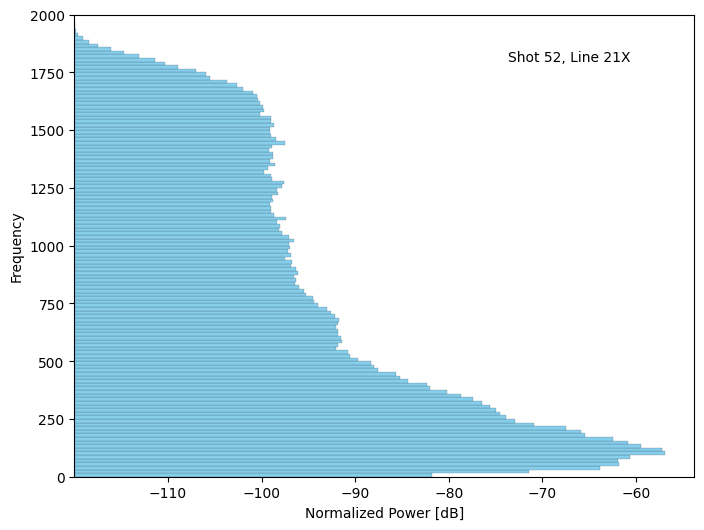

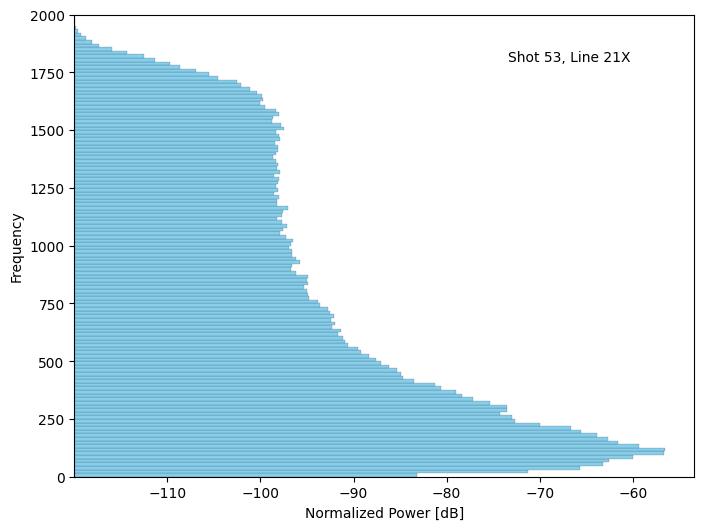

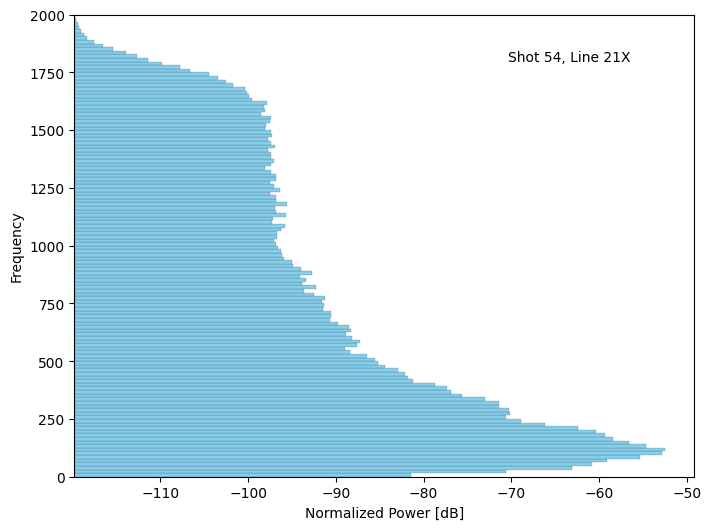

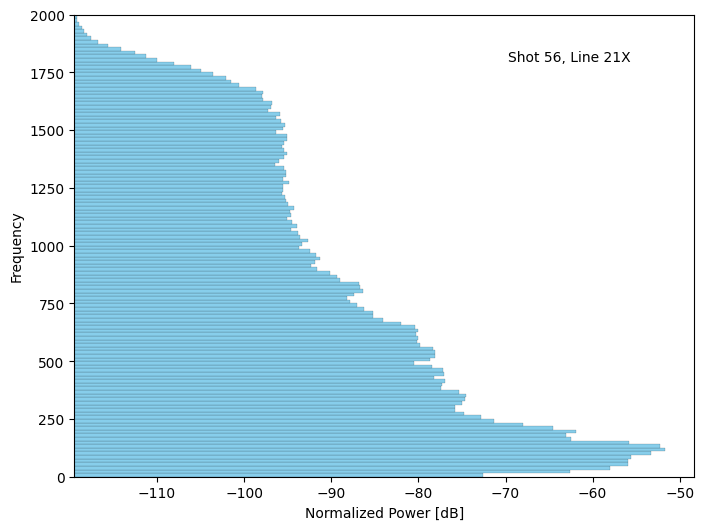

In [24]:
for _bin, db_stack, fldr_number in zip(db_bins, db_stacks, fldr_numbers):
   bins = list(zip(_bin[:-1], _bin[1:]))

   last_start, last_end = bins[-1]
   prev_start, prev_end = bins[-2]

   width = last_end - last_start
   new_bin = (last_end, last_end + width)

   bins.append(new_bin)


   centers = [(b[0] + b[1]) / 2 for b in bins]
   widths  = [b[1] - b[0] for b in bins]
   row_sums = db_stack.sum(axis=1)
   values = row_sums / len(db_stack[0])

   print(len(centers))
   print(len(values))
   print(len(widths))

   fig, ax = plt.subplots(figsize=(8, 6))
   xmin = values.min()   # or whatever left edge you want
   ax.barh(
      centers,
      values - xmin,     # bar length
      left=xmin,         # bar start
      height=widths,
      edgecolor='k',
      linewidth=0.1,
      color='skyblue'
   )

   ax.set_ylabel("Frequency")
   ax.set_xlabel("Normalized Power [dB]")
   ax.set_ylim(0,2000)

   ax.text(0.7, 0.9, f"Shot {fldr_number}, Line {line}", transform=ax.transAxes)

  

In [25]:

import matplotlib.cm as cm
import matplotlib.colors as colors
from pyproj import CRS, Transformer
import shapefile
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def ll2xy(lon: list[float], lat: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y).
    Can also take single floats.

    Parameters
    ----------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326

    Returns
    -------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y

norm = colors.Normalize(vmin=min(fldr_numbers), vmax=max(fldr_numbers))
cmap_viridis = cm.viridis

# Load and plot lake and seismic outlines
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)

# Load seismic data
seismic_path = '../atl11-crossovers/_data/SeismicKSS2_21-22.csv'
seismic = pd.read_csv(seismic_path)
seismic['x'], seismic['y'] = ll2xy(seismic['LONGITUDE'], seismic['LATITUDE'])




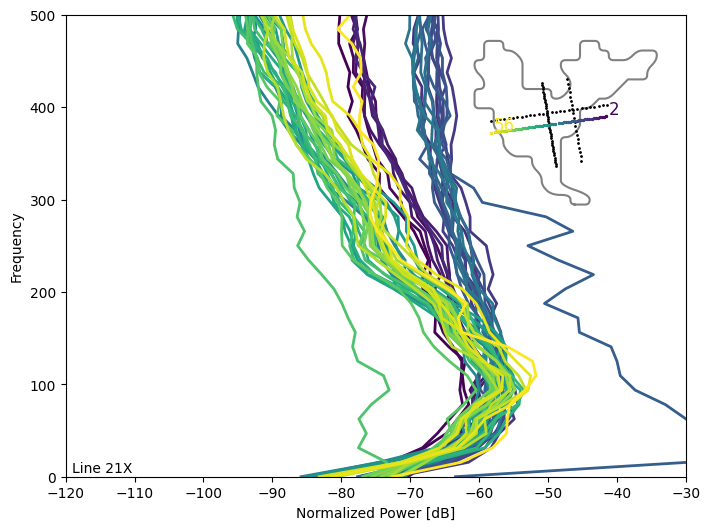

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

for _bin, db_stack, fldr_number in zip(db_bins, db_stacks, fldr_numbers):
    row_sums = db_stack.sum(axis=1)
    values = row_sums / len(db_stack[0])

    color = cmap_viridis(norm(fldr_number))
    ax.plot(
       values,
       _bin,
       c=color,
       linewidth=2)

ax.set_ylabel("Frequency")
ax.set_xlabel("Normalized Power [dB]")
ax.set_ylim(0,500)
ax.set_xlim(-120,-30)

ax.text(0.01, 0.01, f"Line {line}", transform=ax.transAxes)

# Inset with line and labeled shot numbers
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
# Inset
x0, y0, w, h = 0.6, 0.55, 0.3, 0.3
axins = fig.add_axes([x0, y0, w, h], projection=ps71_projection)
axins.spines['geo'].set_visible(False)
axins.scatter(seismic['Shot_X'], seismic['Shot_Y'], s=1, c='black', label='Seismic Shots', transform=ps71_projection)


########## MANUALLY CHOOSE POINTS ###########
#mask = seismic["LABEL"].str.contains("XX", na=False)
mask = seismic["LABEL"].str.contains("X", na=False) & ~seismic["LABEL"].str.contains("XX", na=False)


shots = seismic.loc[mask, "Shot_Num"].values
x_shots = seismic.loc[mask, "Shot_X"].values
y_shots = seismic.loc[mask, "Shot_Y"].values

for shot, x_shot, y_shot in zip(shots, x_shots, y_shots):
    color = cmap_viridis(norm(shot))
    axins.scatter(x_shot,y_shot, s=2, color=color, label='Seismic Shots', transform=ps71_projection)

axins.text(x_shots[0] + 100, y_shots[0] + 100, str(shots[0]), fontsize=12, color=cmap_viridis(norm(shots[0])), transform=ps71_projection)
axins.text(x_shots[-1] + 100, y_shots[-1] + 100, str(shots[-1]), fontsize=12, color=cmap_viridis(norm(shots[-1])), transform=ps71_projection)

for lake_no, (x, y) in enumerate(zip(xs, ys)):
    if lake_no == 0:
        axins.plot(x, y, color='gray', linewidth=1.5, zorder=0,label='David_s1 (Ju et al., 2025)')


axins.patch.set_alpha(0.0)


    


In [36]:
shots

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [10]:
n_freq = len(freqs)
n_traces = S_stack.shape[0] // n_freq

# Repeat frequency axis for all stacked traces
freq_stack = np.tile(freqs, n_traces)
power_stack = S_stack.reshape(-1)
power_db = 10 * np.log10(power_stack + 1e-12)

df = pd.DataFrame({
    "freq": freq_stack,
    "power": power_db
})

freq_bins = np.linspace(freqs.min(), freqs.max(), 50)

df["freq_bin"] = pd.cut(df["freq"], bins=freq_bins)

hist = df.groupby("freq_bin")["power"].mean()



ValueError: All arrays must be of the same length

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(freq_bins[:-1], hist.values, marker="o")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean Power (dB)")
plt.title("Stacked Spectrogram → Frequency Histogram")
plt.grid(True)
plt.show()
